# Industry Sector Employment vs GDP Growth

This notebook analyzes the relationship between **Employment in the Industry Sector (% of total employment)** and **Gross Domestic Product (GDP) Growth** in Sri Lanka.

This explores whether an increase in industrial employment acts as a driver for broader economic growth.

## 1. Data Loading & Initial Exploration

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set directory context for relative paths if needed
if os.path.basename(os.getcwd()) == 'Data_Analysis':
    os.chdir('..')

plt.style.use('default')

# Load GDP Data
gdp_df = pd.read_csv('economy/Gross Domestic Product for Sri Lanka.csv')
gdp_df.rename(columns={'observation_date': 'Year', 'MKTGDPLKA646NWDB': 'GDP'}, inplace=True)
gdp_df['Year'] = pd.to_datetime(gdp_df['Year']).dt.year
gdp_df.set_index('Year', inplace=True)

# Calculate GDP Growth (Year-over-Year % change)
gdp_df['GDP_Growth_%'] = gdp_df['GDP'].pct_change() * 100

print("GDP Data Info:")
print(gdp_df.info())
gdp_df.head()

GDP Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 1960 to 2024
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GDP           65 non-null     float64
 1   GDP_Growth_%  64 non-null     float64
dtypes: float64(2)
memory usage: 1.3 KB
None


,GDP,GDP_Growth_%
Year,,
1960,1.409874e+09,NaN
1961,1.444328e+09,2.443749
1962,1.434156e+09,-0.704227
1963,1.240672e+09,-13.491145
1964,1.309748e+09,5.567597


In [11]:
# Load Industry Employment Data
industry_path = 'labour/finalized_csv/Employment_by_sector_(%)_sl_indicators/Employment in industry (% of total employment) (modeled ILO estimate).csv'
ind_df = pd.read_csv(industry_path)
ind_df = ind_df[['Year', 'Value']].copy()
ind_df.rename(columns={'Value': 'Industry_Employment_%'}, inplace=True)
ind_df['Year'] = ind_df['Year'].astype(int)
ind_df.set_index('Year', inplace=True)

print("Industry Employment Data Info:")
print(ind_df.info())
ind_df.head()

Industry Employment Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2025 to 1991
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Industry_Employment_%  35 non-null     float64
dtypes: float64(1)
memory usage: 560.0 bytes
None


,Industry_Employment_%
Year,
2025,26.304
2024,26.067
2023,26.264
2022,26.488
2021,26.000


## 2. Missing Values Analysis & Imputation

In [13]:
# Fill any missing values with linear interpolation
gdp_clean = gdp_df.interpolate(method='linear').dropna() # Drop first row due to pct_change()
ind_clean = ind_df.interpolate(method='linear').dropna()

print("Preprocessing done.")

Preprocessing done.


## 3. Data Alignment and Merging

In [14]:
# Inner join to guarantee alignment across time
combined_df = gdp_clean.join(ind_clean, how='inner')

print(f"Combined Dataset: {len(combined_df)} records (from {combined_df.index.min()} to {combined_df.index.max()})")
combined_df.head()

Combined Dataset: 34 records (from 1991 to 2024)


,GDP,GDP_Growth_%,Industry_Employment_%
Year,,,
1991,9.000363e+09,12.048618,22.623
1992,9.703012e+09,7.806897,16.945
1993,1.033868e+10,6.551244,17.485
1994,1.171760e+10,13.337531,17.271
1995,1.302970e+10,11.197625,21.174


## 4. Comprehensive Correlation Analysis
Here we analyze if there's a strong statistical relationship between having a higher share of people working in Industry and the country's GDP Growth.

In [6]:
y_vals = combined_df['GDP_Growth_%'].values
x_vals = combined_df['Industry_Employment_%'].values

pearson_r, pearson_p = stats.pearsonr(x_vals, y_vals)
spearman_r, spearman_p = stats.spearmanr(x_vals, y_vals)

print("=" * 60)
print("CORRELATION: Industry Employment vs GDP Growth")
print("=" * 60)
print(f"Pearson (Linear):       r = {pearson_r:.4f}  | p-value = {pearson_p:.6f}")
print(f"Spearman (Monotonic):   Rho = {spearman_r:.4f} | p-value = {spearman_p:.6f}")
print("=" * 60)


CORRELATION: Industry Employment vs GDP Growth
Pearson (Linear):       r = -0.1211  | p-value = 0.494996
Spearman (Monotonic):   Rho = -0.1911 | p-value = 0.278874


## 5. Extensive Visualization

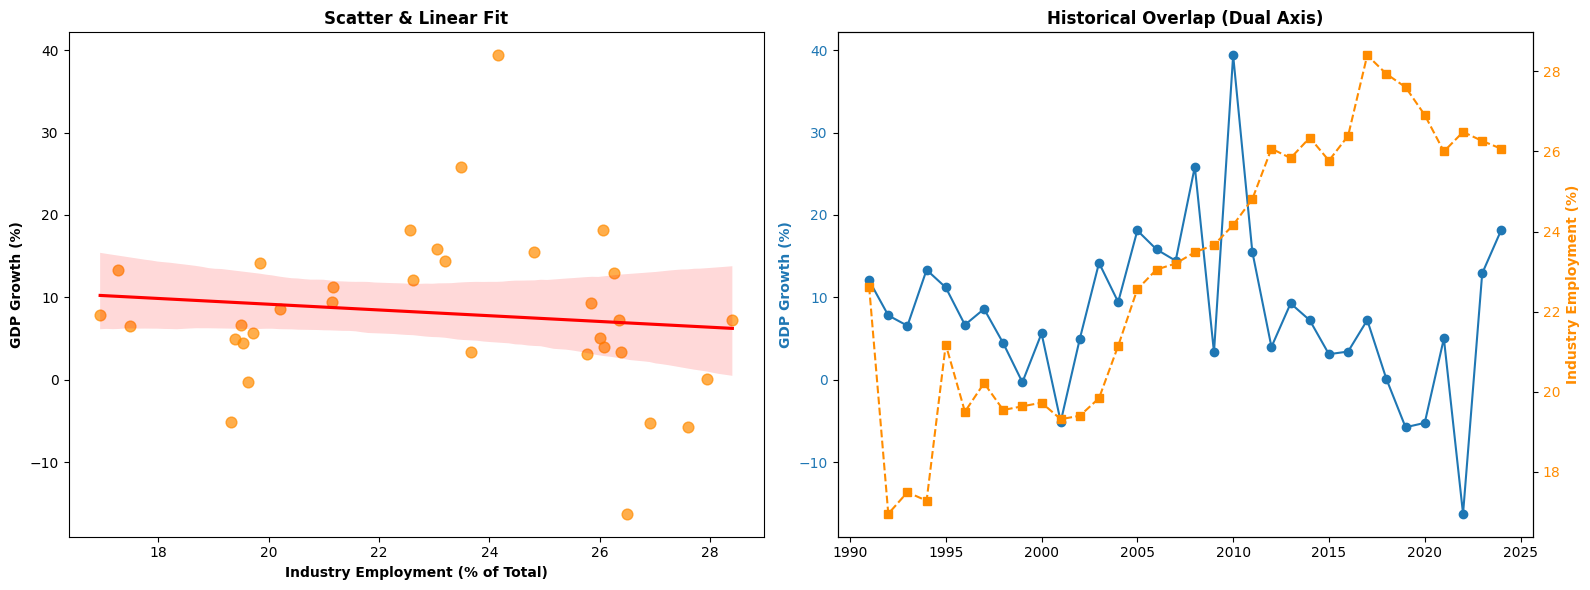

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter with Regression Line
sns.regplot(x=x_vals, y=y_vals, ax=axes[0], scatter_kws={'alpha': 0.7, 's': 60, 'color': 'darkorange'}, line_kws={'color': 'red'})
axes[0].set_xlabel('Industry Employment (% of Total)', fontweight='bold')
axes[0].set_ylabel('GDP Growth (%)', fontweight='bold')
axes[0].set_title('Scatter & Linear Fit', fontweight='bold')

# 2. Time Series Dynamics
ax_time = axes[1]
ax_time.plot(combined_df.index, combined_df['GDP_Growth_%'], color='tab:blue', marker='o', label='GDP Growth')
ax_time.set_ylabel('GDP Growth (%)', color='tab:blue', fontweight='bold')
ax_time.tick_params(axis='y', labelcolor='tab:blue')
ax_twin = ax_time.twinx()
ax_twin.plot(combined_df.index, combined_df['Industry_Employment_%'], color='darkorange', marker='s', linestyle='--', label='Industry Employment')
ax_twin.set_ylabel('Industry Employment (%)', color='darkorange', fontweight='bold')
ax_twin.tick_params(axis='y', labelcolor='darkorange')
ax_time.set_title('Historical Overlap (Dual Axis)', fontweight='bold')

plt.tight_layout()
plt.show()